In [40]:
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


In [42]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=0.4,
    vertical_flip=0.4,
    rotation_range=40,
    shear_range=0.2,
    width_shift_range=0.4,
    height_shift_range=0.4,
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

valid_generator = valid_datagen.flow_from_directory(
    'chest_xray/val',  
    target_size=(128, 128),            
    batch_size=32,
    class_mode='categorical',
    shuffle=False                      
)

Found 967 images belonging to 2 classes.


In [44]:
model = tf.keras.models.load_model('work based project/my_pneumonia_model.keras')

C:\Users\a0597\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step


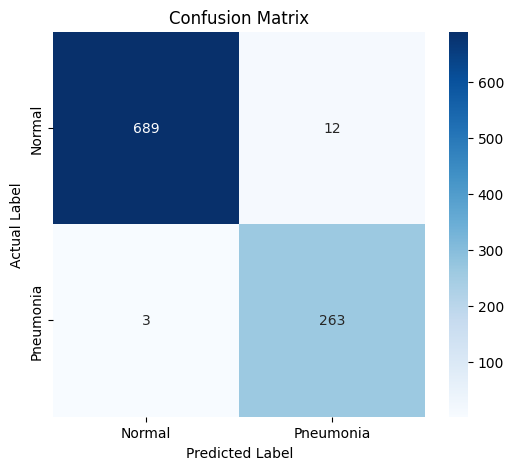

In [46]:
Y_pred = model.predict(valid_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = valid_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       701
   Pneumonia       0.96      0.99      0.97       266

    accuracy                           0.98       967
   macro avg       0.98      0.99      0.98       967
weighted avg       0.98      0.98      0.98       967



31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step


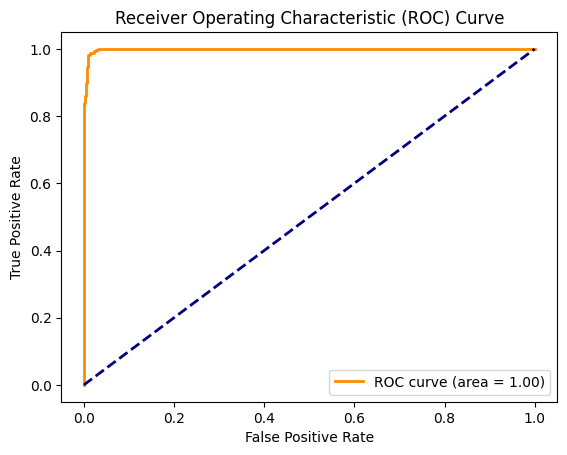

In [ ]:
from sklearn.metrics import roc_curve, auc

y_pred_probs = model.predict(valid_generator)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# 
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [1]:
import os

data_dir = r"C:\Users\a0597\chest_xray"

def count_files(dir_name):
    path = os.path.join(data_dir, dir_name)
    total = 0
    if os.path.exists(path):
        for root, dirs, files in os.walk(path):
            total += sum(1 for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    return total

train_count = count_files("train")
val_count = count_files("val")
test_count = count_files("test")

total_images = train_count + val_count + test_count

print(f"Train: {train_count} images ({(train_count/total_images)*100:.2f}%)")
print(f"Validation: {val_count} images ({(val_count/total_images)*100:.2f}%)")
print(f"Test: {test_count} images ({(test_count/total_images)*100:.2f}%)")

Train: 11342 images (81.85%)
Validation: 967 images (6.98%)
Test: 1548 images (11.17%)
